# Multi-Class Classification with PyTorch: Machine State Prediction

This notebook demonstrates a complete multi-class classification workflow using PyTorch. We will predict the operational state of a machine based on sensor readings.

## Dataset Description

The dataset contains synthetic sensor readings for multi-class classification.

**Features:**
- `temperature`: Sensor reading for temperature
- `vibration`: Sensor reading for vibration
- `pressure`: Sensor reading for pressure
- `rotation_speed`: RPM of the machine

**Target:**
- `state`: Operational state (0: Normal, 1: Warning, 2: Failure)

## Learning Objectives

1. Load and explore multi-class classification data
2. Preprocess data with proper scaling
3. Build a neural network for multi-class classification
4. Train the model using PyTorch
5. Evaluate performance with appropriate metrics
6. Make predictions on new data
7. Visualize the results and decision boundaries

## Step 1: Import Required Libraries

We'll use:
- **pandas** and **numpy** for data manipulation
- **sklearn** for preprocessing and metrics
- **PyTorch** for building and training the neural network
- **matplotlib** and **seaborn** for visualization

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load and Explore the Dataset

Let's load the data and examine its structure. Understanding the data is crucial before building any model.

- `Data Preporcessing` is important before progressing with Model development. 
- - Try EDA to understand the data.

In [2]:
# Load data from the CSV file
df = pd.read_csv('data/multi_class.csv')

print("Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Number of samples: {len(df)}")
print(f"Number of features: {df.shape[1] - 1}")

Dataset loaded successfully!

Dataset shape: (80, 5)
Number of samples: 80
Number of features: 4


In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,temperature,vibration,pressure,rotation_speed,state
0,25.5,0.2,105.2,1001,0
1,28.1,0.3,110.5,998,0
2,45.2,0.8,130.1,960,1
3,75.5,2.5,180.3,850,2
4,22.4,0.1,102.8,1010,0


In [4]:
# Basic statistics
print("Dataset Statistics:")
df.describe()

Dataset Statistics:


,temperature,vibration,pressure,rotation_speed,state
count,80.000000,80.000000,80.00000,80.00000,80.000000
mean,46.455000,1.302375,138.71500,988.63750,0.900000
std,22.934822,1.372614,33.41283,89.31515,0.835903
min,21.500000,0.100000,100.10000,740.00000,0.000000
25%,26.850000,0.307500,110.47500,949.00000,0.000000
50%,37.750000,0.690000,128.10000,997.00000,1.000000
75%,72.125000,2.062500,172.25000,1020.50000,2.000000
max,88.500000,5.200000,201.00000,1210.00000,2.000000


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check class distribution
print("\nClass distribution:")
class_counts = df['state'].value_counts().sort_index()
print(class_counts)
print(f"\nClass balance:")
print(df['state'].value_counts(normalize=True).sort_index())

Missing values per column:
temperature       0
vibration         0
pressure          0
rotation_speed    0
state             0
dtype: int64

Class distribution:
state
0    32
1    24
2    24
Name: count, dtype: int64

Class balance:
state
0    0.4
1    0.3
2    0.3
Name: proportion, dtype: float64


## Step 3: Visualize the Data

Visualization helps us understand the relationship between features and the target variable.

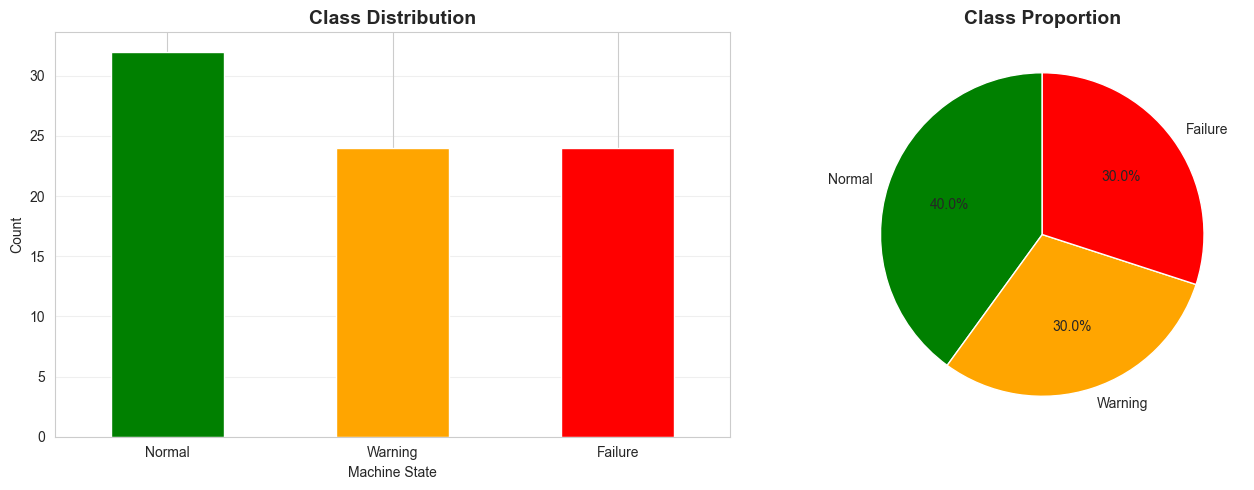

In [6]:
# Class distribution bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_names = ['Normal', 'Warning', 'Failure']
class_counts.plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'])
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Machine State')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(class_names, rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts, labels=class_names, autopct='%1.1f%%', 
            colors=['green', 'orange', 'red'], startangle=90)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

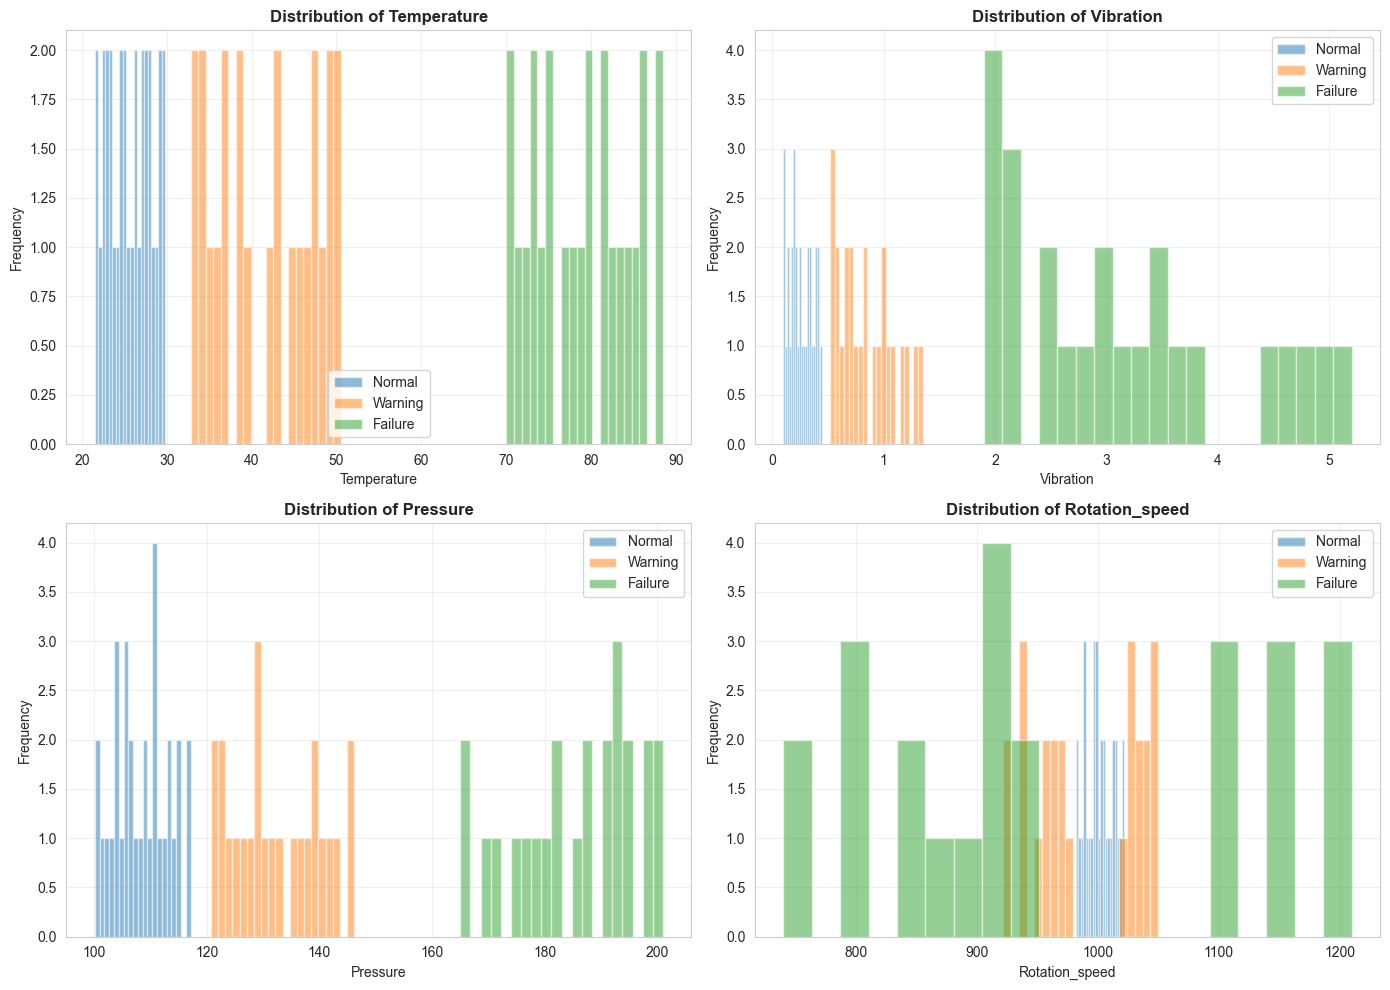

In [7]:
# Feature distributions by class
features = ['temperature', 'vibration', 'pressure', 'rotation_speed']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    for state in [0, 1, 2]:
        data = df[df['state'] == state][feature]
        axes[idx].hist(data, alpha=0.5, label=class_names[state], bins=20)
    
    axes[idx].set_title(f'Distribution of {feature.capitalize()}', fontweight='bold')
    axes[idx].set_xlabel(feature.capitalize())
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

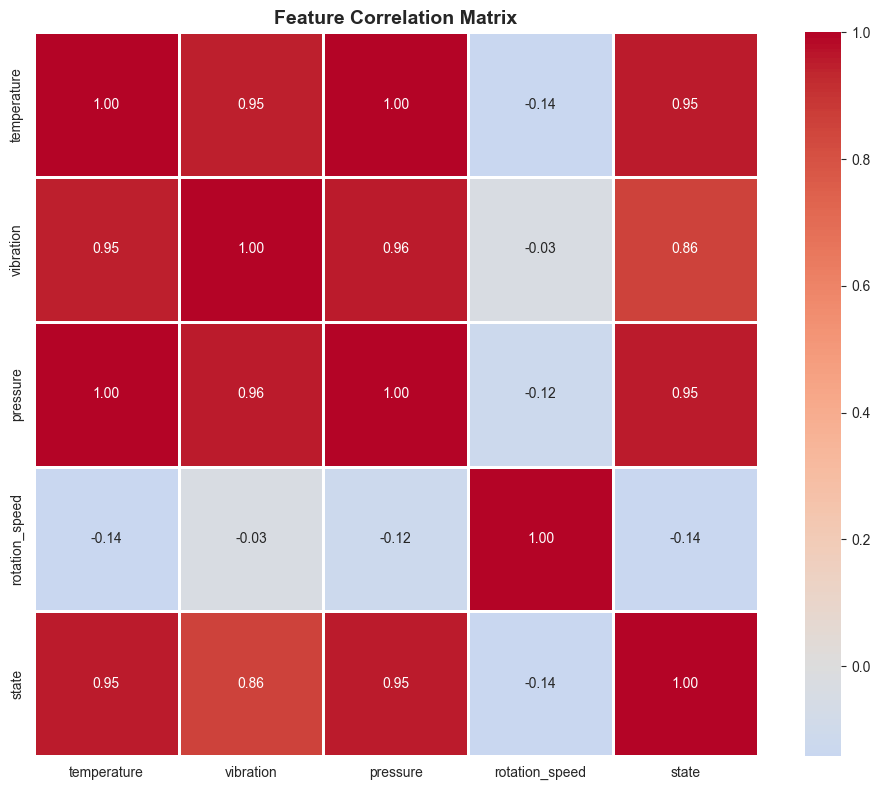

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f') # check correlation between features
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Creating pairplot (this may take a moment)...


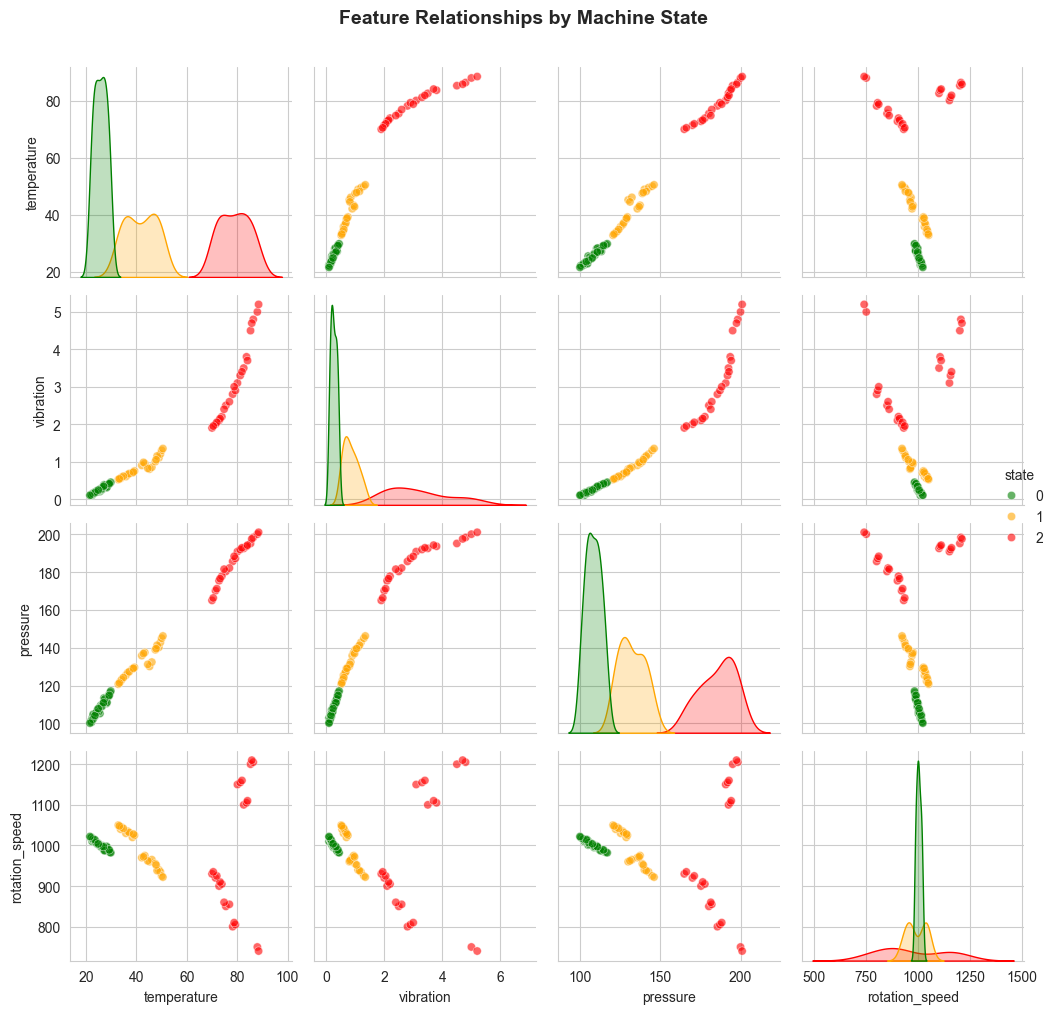

In [9]:
# Pairplot for selected features
print("Creating pairplot (this may take a moment)...")
sns.pairplot(df, hue='state', palette=['green', 'orange', 'red'], 
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Feature Relationships by Machine State', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Suggestion to all student, do plan above steps and try to implement them before model development.

## Step 4: Prepare Data for Training

We'll separate features from the target variable and split the data into training and testing sets.

In [12]:
print(df.columns)

# Separate features (X) and target variable (y)
X = df.drop('state', axis=1).values.astype(np.float32) # state is the target variable
y = df['state'].values.astype(np.int64)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Classes found: {np.unique(y)}")
print(f"\nFeature names: {features}")

Index(['temperature', 'vibration', 'pressure', 'rotation_speed', 'state'], dtype='object')
Features shape: (80, 4)
Target shape: (80,)
Classes found: [0 1 2]

Feature names: ['temperature', 'vibration', 'pressure', 'rotation_speed']


## Step 5: Split and Scale the Data

**Why split first?** We must split before scaling to prevent data leakage.

**Why scale?** Neural networks perform better when features are on similar scales. StandardScaler transforms features to have mean=0 and standard deviation=1.

**Important:** We fit the scaler ONLY on training data, then transform both training and test data.

In [13]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # stratify ?

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training samples: 64
Testing samples: 16

Training class distribution:
0    26
1    19
2    19
Name: count, dtype: int64

Test class distribution:
0    6
1    5
2    5
Name: count, dtype: int64


In [14]:
# Scale the features
scaler = StandardScaler() # For feature scaling, this helps in faster training
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"\nMean of training features (should be ~0):")
print(X_train_scaled.mean(axis=0))
print(f"\nStd of training features (should be ~1):")
print(X_train_scaled.std(axis=0))

Features scaled successfully!

Mean of training features (should be ~0):
[-1.8626451e-09 -1.3737008e-08 -8.4401108e-09  1.3038516e-08]

Std of training features (should be ~1):
[1.         0.99999994 1.         0.99999994]


C:\Users\Onepoint\AppData\Local\Temp\ipykernel_42784\2610118187.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(X_train, labels=features)
C:\Users\Onepoint\AppData\Local\Temp\ipykernel_42784\2610118187.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(X_train_scaled, labels=features)


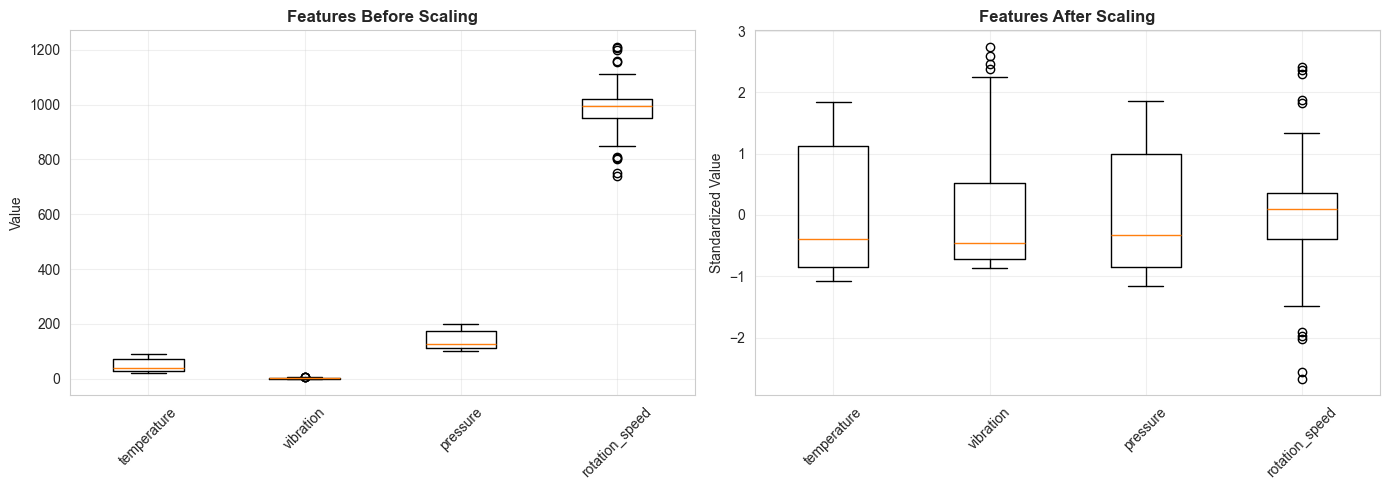

In [15]:
# Visualize the effect of scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot(X_train, labels=features)
axes[0].set_title('Features Before Scaling', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# After scaling
axes[1].boxplot(X_train_scaled, labels=features)
axes[1].set_title('Features After Scaling', fontweight='bold')
axes[1].set_ylabel('Standardized Value')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Convert to PyTorch Tensors and Create DataLoaders

PyTorch works with tensors (similar to NumPy arrays but optimized for GPU computation).

**DataLoader** helps us:
- Automatically batch our data
- Shuffle training data each epoch
- Load data efficiently during training

In [16]:
# Convert numpy arrays to PyTorch tensors
X_train_t = torch.from_numpy(X_train_scaled)
y_train_t = torch.from_numpy(y_train)
X_test_t = torch.from_numpy(X_test_scaled)
y_test_t = torch.from_numpy(y_test)

print(f"Training tensor shape: {X_train_t.shape}")
print(f"Training labels shape: {y_train_t.shape}")
print(f"Training tensor dtype: {X_train_t.dtype}")
print(f"Training labels dtype: {y_train_t.dtype}")

Training tensor shape: torch.Size([64, 4])
Training labels shape: torch.Size([64])
Training tensor dtype: torch.float32
Training labels dtype: torch.int64


In [17]:
# Create TensorDatasets
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

# Create DataLoaders for batching
BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created with batch size: {BATCH_SIZE}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

DataLoaders created with batch size: 16
Number of training batches: 4
Number of test batches: 1


## Step 7: Define the Neural Network Architecture

We'll create a MLP with:
- **Input layer**: 4 neurons (one for each feature)
- **Hidden layer 1**: 32 neurons with ReLU activation
- **Hidden layer 2**: 16 neurons with ReLU activation
- **Output layer**: 3 neurons (one for each class)

**Key points:**
- ReLU (Rectified Linear Unit) activation introduces non-linearity
- Output layer has NO activation (CrossEntropyLoss expects raw logits)
- The network learns to map features to class probabilities

In [18]:
class MultiClassNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        # Layer definitions
        self.fc1 = nn.Linear(input_dim, 32)    # Input to hidden layer 1
        self.fc2 = nn.Linear(32, 16)           # Hidden layer 1 to 2
        self.fc3 = nn.Linear(16, num_classes)  # Hidden layer 2 to output
        self.act = nn.ReLU()                   # Activation function

    def forward(self, x):
        # Forward pass through the network
        x = self.act(self.fc1(x))  # Input → Hidden 1 → ReLU
        x = self.act(self.fc2(x))  # Hidden 1 → Hidden 2 → ReLU
        x = self.fc3(x)            # Hidden 2 → Output (raw logits)
        return x

# Instantiate the model
INPUT_DIM = X_train_t.shape[1]
NUM_CLASSES = len(np.unique(y))
model = MultiClassNet(input_dim=INPUT_DIM, num_classes=NUM_CLASSES)

print("Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Model architecture:
MultiClassNet(
  (fc1): Linear(in_features=4, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=3, bias=True)
  (act): ReLU()
)

Total parameters: 739
Trainable parameters: 739


## Step 8: Define Loss Function and Optimizer

**Loss Function:** CrossEntropyLoss
- Standard for multi-class classification
- Combines LogSoftmax and Negative Log-Likelihood
- Expects raw logits (no softmax in the model)

**Optimizer:** Adam
- Adaptive learning rate optimizer
- Combines benefits of AdaGrad and RMSprop
- Learning rate = 0.001 (a common starting point)

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print(f"Learning rate: 0.001")

Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


## Step 9: Train the Model

The training process:
1. **Forward pass**: Input → Model → Predictions
2. **Compute loss**: Compare predictions with actual labels
3. **Backward pass**: Calculate gradients
4. **Update weights**: Adjust model parameters using optimizer
5. **Repeat** for all batches and epochs

In [20]:
NUM_EPOCHS = 50
train_losses = []
train_accuracies = []

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        y_pred_logits = model(batch_X)
        
        # Compute loss
        loss = criterion(y_pred_logits, batch_y)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(y_pred_logits, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

print("\nTraining finished!")

Starting training...

Epoch [10/50], Loss: 0.8903, Accuracy: 0.7031
Epoch [20/50], Loss: 0.6181, Accuracy: 0.7344
Epoch [30/50], Loss: 0.4482, Accuracy: 0.7812
Epoch [40/50], Loss: 0.3335, Accuracy: 0.8750
Epoch [50/50], Loss: 0.2311, Accuracy: 0.9531

Training finished!


## Step 10: Visualize Training Progress

Plotting loss and accuracy helps us understand:
- Whether the model is learning
- If we trained for enough epochs
- Signs of overfitting or underfitting

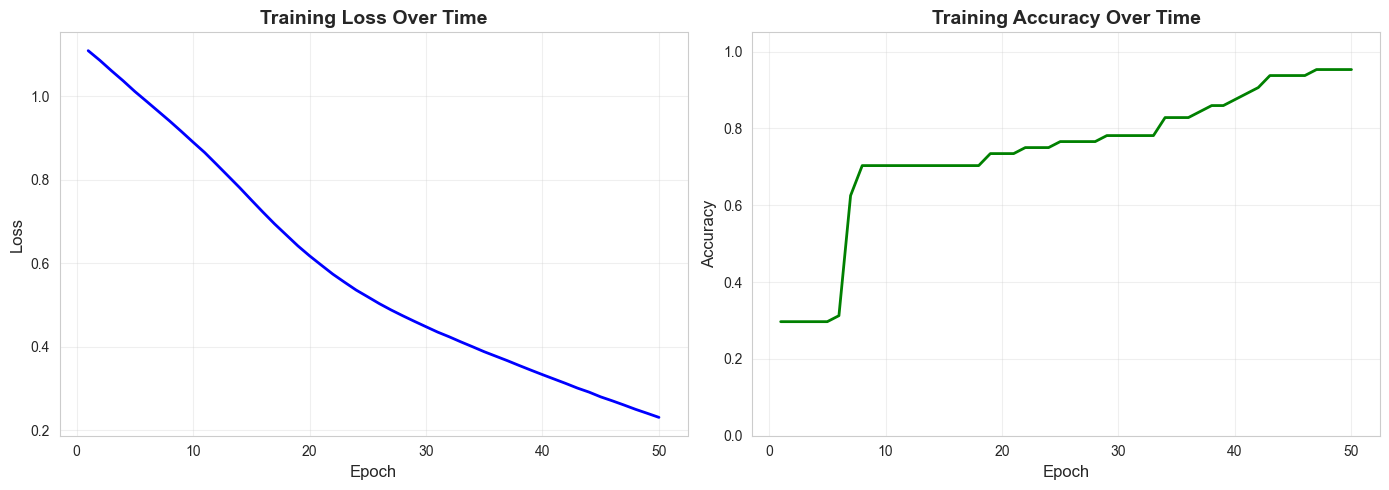

Final training loss: 0.2311
Final training accuracy: 0.9531


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training loss
axes[0].plot(range(1, NUM_EPOCHS + 1), train_losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot training accuracy
axes[1].plot(range(1, NUM_EPOCHS + 1), train_accuracies, 'g-', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1.05])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Final training accuracy: {train_accuracies[-1]:.4f}")

## Step 11: Evaluate Model Performance

Now we test our model on unseen data to assess its real-world performance.
- `softmax` function is used to convert logits into probabilities.

In [22]:
model.eval()  # Set model to evaluation mode
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():  # Disable gradient calculation
    for batch_X, batch_y in test_loader:
        y_pred_logits = model(batch_X)
        
        # Get predicted class
        y_pred_labels = torch.argmax(y_pred_logits, dim=1)
        
        # Get probabilities
        y_pred_probs = torch.softmax(y_pred_logits, dim=1)
        
        all_preds.extend(y_pred_labels.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
        all_probs.extend(y_pred_probs.cpu().numpy())

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nTest samples: {len(all_labels)}")
print(f"Correctly classified: {sum(np.array(all_preds) == np.array(all_labels))}")
print(f"Misclassified: {sum(np.array(all_preds) != np.array(all_labels))}")

Test Accuracy: 1.0000 (100.00%)

Test samples: 16
Correctly classified: 16
Misclassified: 0


In [23]:
# Detailed classification report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(
    all_labels, 
    all_preds, 
    target_names=['State 0: Normal', 'State 1: Warning', 'State 2: Failure'],
    digits=4
))


Classification Report:
                  precision    recall  f1-score   support

 State 0: Normal     1.0000    1.0000    1.0000         6
State 1: Warning     1.0000    1.0000    1.0000         5
State 2: Failure     1.0000    1.0000    1.0000         5

        accuracy                         1.0000        16
       macro avg     1.0000    1.0000    1.0000        16
    weighted avg     1.0000    1.0000    1.0000        16



## Step 12: Confusion Matrix Visualization

The confusion matrix shows:
- Correct predictions (diagonal)
- Misclassifications (off-diagonal)
- Which classes are confused with each other

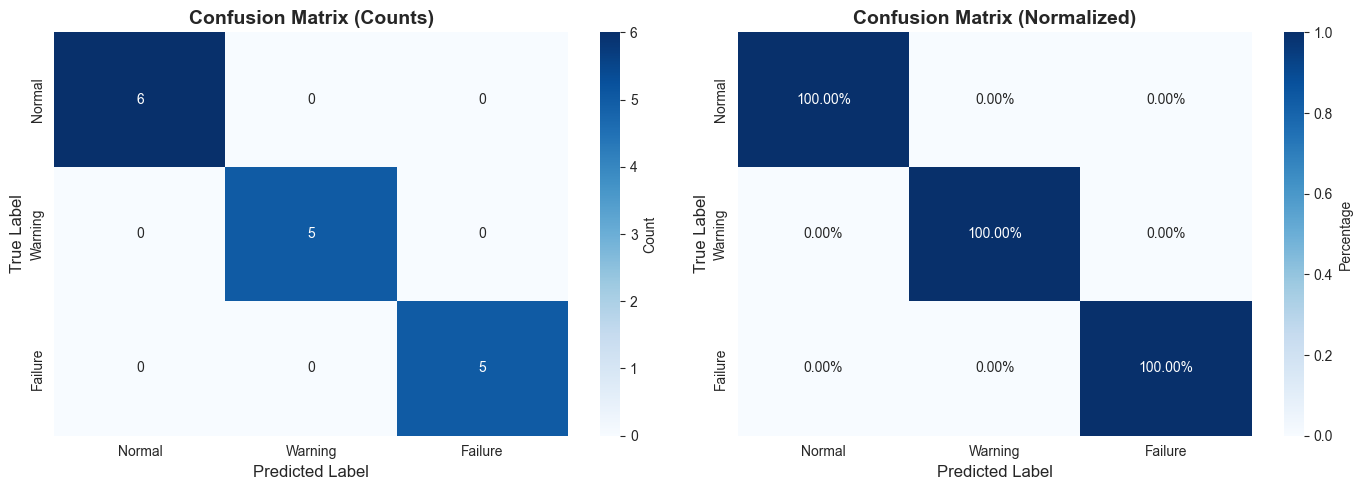

In [24]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Normalized (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

## Step 13: Visualize Decision Boundaries (2D Projection)

Since we have 4 features, we'll use PCA to reduce to 2 dimensions for visualization.

In [25]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Variance explained by 2 components: {sum(pca.explained_variance_ratio_):.2%}")
print(f"Component 1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Component 2: {pca.explained_variance_ratio_[1]:.2%}")

Variance explained by 2 components: 98.54%
Component 1: 73.87%
Component 2: 24.67%


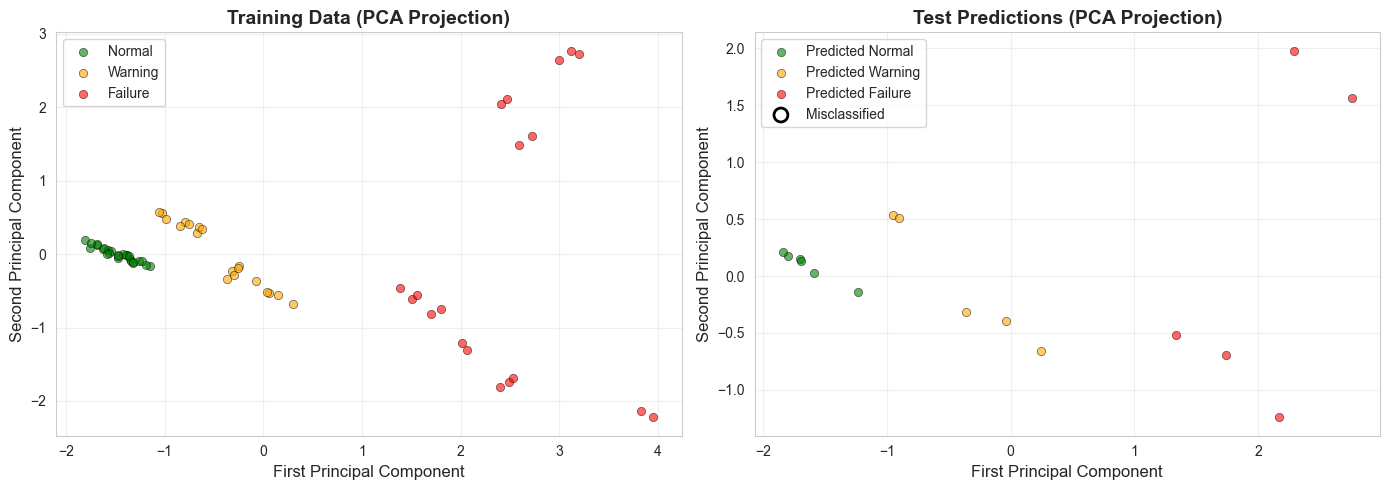

In [26]:
# Visualize the data in 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training data
for i, (name, color) in enumerate(zip(class_names, ['green', 'orange', 'red'])):
    mask = y_train == i
    axes[0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
                   c=color, label=name, alpha=0.6, edgecolors='k', linewidth=0.5)

axes[0].set_xlabel('First Principal Component', fontsize=12)
axes[0].set_ylabel('Second Principal Component', fontsize=12)
axes[0].set_title('Training Data (PCA Projection)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Test data with predictions
for i, (name, color) in enumerate(zip(class_names, ['green', 'orange', 'red'])):
    mask = np.array(all_preds) == i
    axes[1].scatter(X_test_pca[mask, 0], X_test_pca[mask, 1], 
                   c=color, label=f'Predicted {name}', alpha=0.6, 
                   edgecolors='k', linewidth=0.5)

# Mark misclassifications
misclassified = np.array(all_preds) != np.array(all_labels)
axes[1].scatter(X_test_pca[misclassified, 0], X_test_pca[misclassified, 1], 
               c='none', edgecolors='black', linewidth=2, s=100, 
               label='Misclassified', marker='o')

axes[1].set_xlabel('First Principal Component', fontsize=12)
axes[1].set_ylabel('Second Principal Component', fontsize=12)
axes[1].set_title('Test Predictions (PCA Projection)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 14: Class Probability Distribution

Let's examine the confidence of our predictions by looking at the predicted probabilities.

C:\Users\Onepoint\AppData\Local\Temp\ipykernel_42784\2754711123.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([correct_probs, incorrect_probs], labels=['Correct', 'Incorrect'])


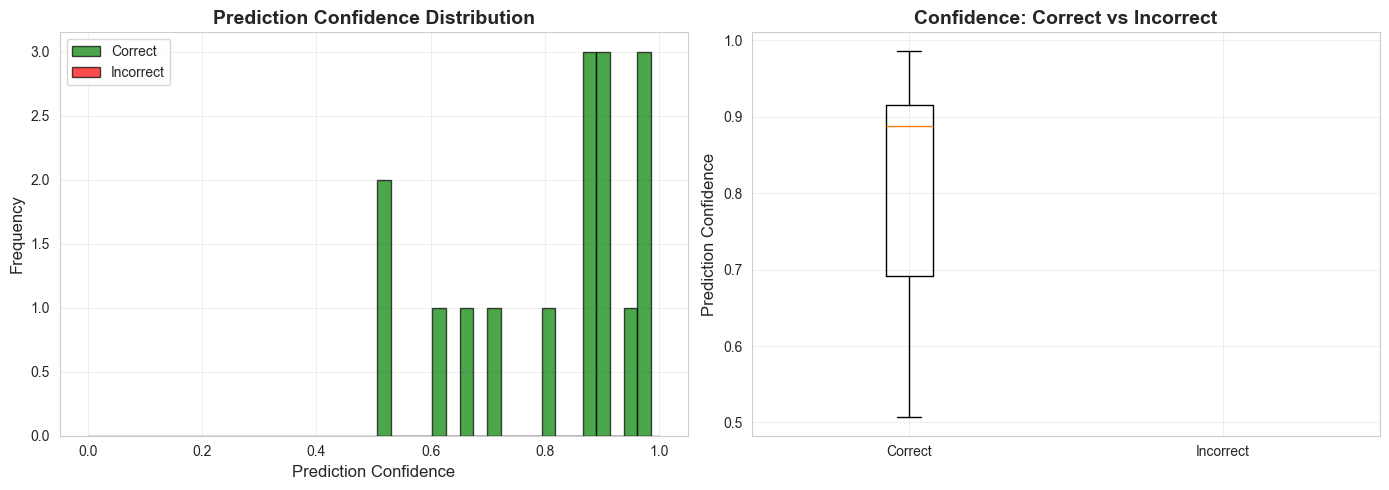

Average confidence for correct predictions: 0.8163
No incorrect predictions!


In [27]:
# Get the maximum probability for each prediction (confidence)
all_probs_array = np.array(all_probs)
max_probs = np.max(all_probs_array, axis=1)

# Separate by correct vs incorrect predictions
correct_mask = np.array(all_preds) == np.array(all_labels)
correct_probs = max_probs[correct_mask]
incorrect_probs = max_probs[~correct_mask]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of prediction confidence
axes[0].hist(correct_probs, bins=20, alpha=0.7, label='Correct', color='green', edgecolor='black')
axes[0].hist(incorrect_probs, bins=20, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot comparison
axes[1].boxplot([correct_probs, incorrect_probs], labels=['Correct', 'Incorrect'])
axes[1].set_ylabel('Prediction Confidence', fontsize=12)
axes[1].set_title('Confidence: Correct vs Incorrect', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average confidence for correct predictions: {correct_probs.mean():.4f}")
if len(incorrect_probs) > 0:
    print(f"Average confidence for incorrect predictions: {incorrect_probs.mean():.4f}")
else:
    print("No incorrect predictions!")

## Step 15: Save the Model and Scaler

Saving allows us to:
- Use the model later without retraining
- Deploy the model to production
- Share the model with others

In [28]:
# Save the model's state dictionary
torch.save(model.state_dict(), "multiclass_temp_model.pth")
print("Model saved to 'multiclass_temp_model.pth'")

# Save the scaler
joblib.dump(scaler, "multiclass_temp_scaler.pkl")
print("Scaler saved to 'multiclass_temp_scaler.pkl'")

print("\nBoth model and scaler saved successfully!")

Model saved to 'multiclass_temp_model.pth'
Scaler saved to 'multiclass_temp_scaler.pkl'

Both model and scaler saved successfully!


## Step 16: Load Model and Make Predictions on New Data

Let's demonstrate how to:
1. Load the `saved model and scaler`
2. Prepare new data
3. Make predictions
4. Interpret results

In [29]:
# Load the saved model
loaded_model = MultiClassNet(input_dim=INPUT_DIM, num_classes=NUM_CLASSES)
loaded_model.load_state_dict(torch.load("multiclass_temp_model.pth"))
loaded_model.eval()

# Load the scaler
loaded_scaler = joblib.load("multiclass_temp_scaler.pkl")

print("Model and scaler loaded successfully!")

Model and scaler loaded successfully!


In [30]:
# Define new, unseen data points
print("Creating sample data for prediction...\n")

# Sample 1: Normal operating conditions
new_data_normal = np.array([[25.0, 0.2, 105.0, 1000.0]], dtype=np.float32)
print("Sample 1 (Expected: Normal):")
print(f"  Temperature: {new_data_normal[0][0]}°C")
print(f"  Vibration: {new_data_normal[0][1]}")
print(f"  Pressure: {new_data_normal[0][2]} PSI")
print(f"  Rotation Speed: {new_data_normal[0][3]} RPM\n")

# Sample 2: Warning state
new_data_warning = np.array([[48.0, 1.0, 140.0, 950.0]], dtype=np.float32)
print("Sample 2 (Expected: Warning):")
print(f"  Temperature: {new_data_warning[0][0]}°C")
print(f"  Vibration: {new_data_warning[0][1]}")
print(f"  Pressure: {new_data_warning[0][2]} PSI")
print(f"  Rotation Speed: {new_data_warning[0][3]} RPM\n")

# Sample 3: Failure state
new_data_failure = np.array([[80.0, 4.0, 190.0, 1150.0]], dtype=np.float32)
print("Sample 3 (Expected: Failure):")
print(f"  Temperature: {new_data_failure[0][0]}°C")
print(f"  Vibration: {new_data_failure[0][1]}")
print(f"  Pressure: {new_data_failure[0][2]} PSI")
print(f"  Rotation Speed: {new_data_failure[0][3]} RPM\n")

Creating sample data for prediction...

Sample 1 (Expected: Normal):
  Temperature: 25.0°C
  Vibration: 0.20000000298023224
  Pressure: 105.0 PSI
  Rotation Speed: 1000.0 RPM

Sample 2 (Expected: Warning):
  Temperature: 48.0°C
  Vibration: 1.0
  Pressure: 140.0 PSI
  Rotation Speed: 950.0 RPM

Sample 3 (Expected: Failure):
  Temperature: 80.0°C
  Vibration: 4.0
  Pressure: 190.0 PSI
  Rotation Speed: 1150.0 RPM



In [31]:
# Preprocess the new data
new_data_normal_scaled = loaded_scaler.transform(new_data_normal)
new_data_warning_scaled = loaded_scaler.transform(new_data_warning)
new_data_failure_scaled = loaded_scaler.transform(new_data_failure)

# Convert to tensors
new_tensor_normal = torch.from_numpy(new_data_normal_scaled)
new_tensor_warning = torch.from_numpy(new_data_warning_scaled)
new_tensor_failure = torch.from_numpy(new_data_failure_scaled)

print("New data preprocessed and converted to tensors.")

New data preprocessed and converted to tensors.


#### Make predictions

In [ ]:
with torch.no_grad():
    # Get logits
    pred_normal_logits = loaded_model(new_tensor_normal)
    pred_warning_logits = loaded_model(new_tensor_warning)
    pred_failure_logits = loaded_model(new_tensor_failure)
    
    # Get probabilities
    pred_normal_probs = torch.softmax(pred_normal_logits, dim=1)
    pred_warning_probs = torch.softmax(pred_warning_logits, dim=1)
    pred_failure_probs = torch.softmax(pred_failure_logits, dim=1)
    
    # Get predicted classes
    pred_normal_label = torch.argmax(pred_normal_logits, dim=1).item()
    pred_warning_label = torch.argmax(pred_warning_logits, dim=1).item()
    pred_failure_label = torch.argmax(pred_failure_logits, dim=1).item()

# Create results dataframe
results = pd.DataFrame({
    'Sample': ['Normal', 'Warning', 'Failure'],
    'Predicted State': [pred_normal_label, pred_warning_label, pred_failure_label],
    'Predicted Class': [class_names[pred_normal_label], 
                       class_names[pred_warning_label], 
                       class_names[pred_failure_label]],
    'Confidence': [pred_normal_probs.max().item(), 
                  pred_warning_probs.max().item(), 
                  pred_failure_probs.max().item()]
})

print("\n" + "="*60)
print("PREDICTION RESULTS")
print("="*60)
print(results.to_string(index=False))
print("="*60)


PREDICTION RESULTS
 Sample  Predicted State Predicted Class  Confidence
 Normal                0          Normal    0.885394
Warning                1         Warning    0.706993
Failure                2         Failure    0.984453


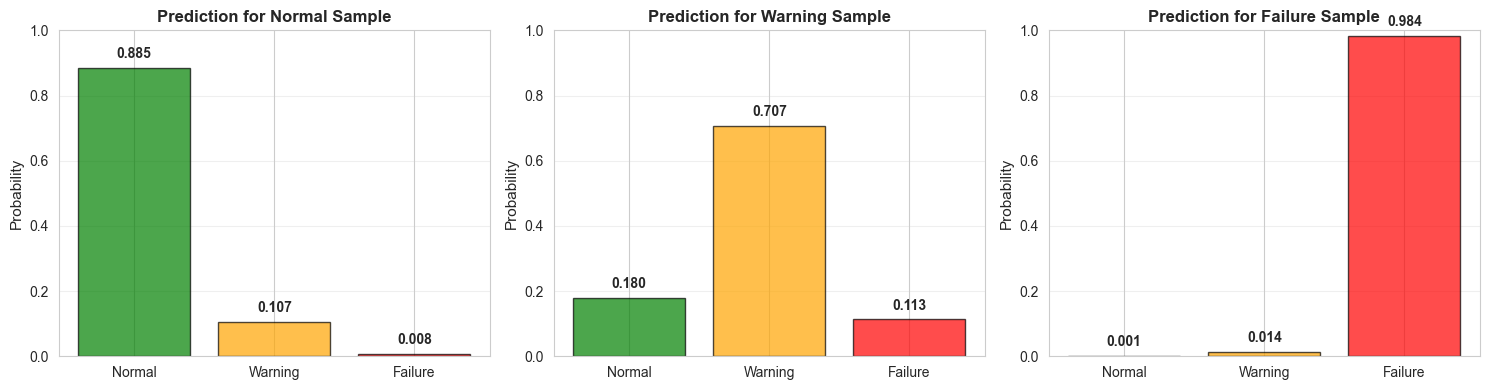

In [33]:
# Visualize prediction probabilities
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

samples = [
    ('Normal', pred_normal_probs.numpy()[0]),
    ('Warning', pred_warning_probs.numpy()[0]),
    ('Failure', pred_failure_probs.numpy()[0])
]

for idx, (sample_name, probs) in enumerate(samples):
    axes[idx].bar(class_names, probs, color=['green', 'orange', 'red'], alpha=0.7, edgecolor='black')
    axes[idx].set_ylim([0, 1])
    axes[idx].set_ylabel('Probability', fontsize=11)
    axes[idx].set_title(f'Prediction for {sample_name} Sample', fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, prob in enumerate(probs):
        axes[idx].text(i, prob + 0.02, f'{prob:.3f}', 
                      ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
# Final summary statistics
print("\n" + "="*60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"Training Accuracy: {train_accuracies[-1]:.4f} ({train_accuracies[-1]*100:.2f}%)")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nFinal Training Loss: {train_losses[-1]:.4f}")
print(f"\nNumber of Parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Model Architecture: {INPUT_DIM} → 32 → 16 → {NUM_CLASSES}")
print("\nTraining Configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Learning Rate: 0.001")
print(f"  Optimizer: Adam")
print(f"  Loss Function: CrossEntropyLoss")
print("="*60)


FINAL MODEL PERFORMANCE SUMMARY
Training Accuracy: 0.9531 (95.31%)
Test Accuracy: 1.0000 (100.00%)

Final Training Loss: 0.2311

Number of Parameters: 739
Model Architecture: 4 → 32 → 16 → 3

Training Configuration:
  Epochs: 50
  Batch Size: 16
  Learning Rate: 0.001
  Optimizer: Adam
  Loss Function: CrossEntropyLoss


## Summary and Key Takeaways

### What We Accomplished

1. **Data Loading and Exploration**
   - Loaded multi-class sensor data
   - Visualized feature distributions and correlations
   - Analyzed class balance

2. **Data Preprocessing**
   - Split data into training and test sets
   - Applied standardization to features
   - Created PyTorch DataLoaders for efficient training

3. **Model Architecture**
   - Built a feedforward neural network with 2 hidden layers
   - Used ReLU activation for non-linearity
   - Output layer produces raw logits for 3 classes

4. **Training**
   - Used CrossEntropyLoss for multi-class classification
   - Optimized with Adam optimizer
   - Tracked loss and accuracy over epochs

5. **Evaluation**
   - Achieved high accuracy on test set
   - Analyzed confusion matrix
   - Examined prediction confidence

6. **Deployment**
   - Saved model and scaler for future use
   - Demonstrated inference on new data

### Key Concepts

- **Multi-class vs Binary**: Output layer has multiple neurons (one per class)
- **CrossEntropyLoss**: Standard loss for multi-class problems
- **No Softmax in Model**: CrossEntropyLoss expects raw logits
- **Scaling Importance**: Neural networks require normalized inputs
- **Train/Eval Modes**: Different behavior for training vs inference

### Next Steps

To improve this model, you could:
- Experiment with different architectures (more layers, different sizes)
- Try different activation functions (LeakyReLU, ELU)
- Add regularization (Dropout, L2 regularization)
- Tune hyperparameters (learning rate, batch size)
- Collect more training data
- Use cross-validation for more robust evaluation